<div align="center" style="
    padding: 15px;
    border-radius: 12px;
    background: linear-gradient(135deg, #0F2027, #203A43, #2C5364);
    box-shadow: 0px 4px 20px rgba(0,0,0,0.4);">

<h1 style="
    color: #4FC3F7;
    font-size: 38px;
    margin: 0;
    font-weight: bold;">
Rocket Nozzle Design  
</h1>

<p style="
    color: #B0BEC5;
    font-size: 16px;
    margin-top: 5px;">
Flow Calculations • Simulation • Geometry
</p>

</div>

<p align="center">
  <img src="https://img.shields.io/badge/Python-3.x-blue?style=for-the-badge&logo=python"/>
  <img src="https://img.shields.io/badge/Aerospace-Propulsion-black?style=for-the-badge"/>
  <img src="https://img.shields.io/badge/Focus-Nozzle%20Design-orange?style=for-the-badge"/>
  <img src="https://img.shields.io/badge/Status-Active-success?style=for-the-badge"/>
</p>

## <span style = "color: lightgreen">Rocket Nozzle Design Calculations</span>
### Given Parameters

| Parameter | Variable | Parameter | Variable |
| :--- | :--- | :--- | :--- |
| **Thrust (N)** | $F$ | **Chamber Temp (K)** | $T_c$ |
| **Chamber Pressure (Pa)** | $P_c$ | **Specific Heat Ratio** | $\gamma$ |
| **Exit Pressure (Pa)** | $P_e$ | **Gas Constant (J/kg·K)** | $R$ |



###  Flow & Area Dynamics

| Metric | Formula | Metric | Formula |
| :--- | :--- | :--- | :--- |
| **Exit Velocity** | $\displaystyle V_e = \sqrt{\frac{2\gamma}{\gamma - 1} \cdot R T_c \cdot \left(1 - \left(\frac{P_e}{P_c}\right)^{\frac{\gamma - 1}{\gamma}}\right)}$ | **Exit Mach No.** | $\displaystyle M_e = \sqrt{\frac{2}{\gamma - 1} \left[ \left(\frac{P_c}{P_e}\right)^{\frac{\gamma - 1}{\gamma}} - 1 \right]}$ |
| **Mass Flow Rate** | $\displaystyle \dot{m} = \frac{F}{V_e}$ | **Area Ratio** | $\displaystyle \frac{A_e}{A_t} = \frac{1}{M_e} \left[ \frac{1 + \frac{\gamma - 1}{2} M_e^2}{\frac{\gamma + 1}{2}} \right]^{\frac{\gamma + 1}{2(\gamma - 1)}}$ |
| **Throat Area** | $\displaystyle A_t = \frac{\dot{m}}{P_c} \cdot \sqrt{\frac{R T_c}{\gamma} \cdot \left(\frac{\gamma + 1}{2}\right)^{\frac{\gamma + 1}{2(\gamma - 1)}}}$ | **Exit Area** | $\displaystyle A_e = A_t \cdot \frac{A_e}{A_t}$ |
| **Throat Diameter** | $\displaystyle d_t = \sqrt{\frac{4A_t}{\pi}}$ | **Exit Diameter** | $\displaystyle d_e = \sqrt{\frac{4A_e}{\pi}}$ |



###  Geometry & Structural Design

| Metric | Formula | Metric | Formula |
| :--- | :--- | :--- | :--- |
| **Chamber Diameter** | $\displaystyle d_c = 3 d_t$ | **Convergent Length** | $\displaystyle L_{conv} = \frac{d_c - d_t}{2 \tan(\alpha)}$ |
| **Chamber Area** | $\displaystyle A_c = \frac{\pi d_c^2}{4}$ | **Divergent Length** | $\displaystyle L_{div} = \frac{d_e - d_t}{2 \tan(\beta)}$ |
| **Chamber Length** | $\displaystyle L_c = \frac{L^* \cdot A_t}{A_c}$ | **Total Length** | $\displaystyle L_{total} = L_c + L_{conv} + L_{div}$ |
| **Wall Thickness** | $\displaystyle t_w = \frac{P_c \cdot d_c}{16000}$ | **Stress Check** | $\displaystyle \sigma = \frac{P_c \cdot d_c}{2 t_w}$ |
| **Design Thickness** | $\displaystyle t = \frac{P_c \cdot d_c \cdot SF}{2 \sigma_{yield}}$ | | |

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import importlib
import atmosphere_data as at_data
import pandas as pd
from matplotlib.patches import Arc

# Parameters
g = 9.80665

f = 3000     # N
pc = 3.468e6 # mpa - pa (e6) Chamber pressure
pe = 0.02e6  # mpa - pa (e6) (Expantions Ratio) for Liquid engine if Solid (0.1e6)
tc = 3300    # K  - Chamber Tempreture
y = 1.22     # or K Specific heat ratio
r = 355.4    # J/Kgh   gas constant

pi = np.pi

sy = 250e6  # Pa for thickness
SF = 2

# angles
divergent_angle = 15 #(12 - 18)
convergent_a = 30 #(30 - 45)


da = np.radians(divergent_angle)
ca = np.radians(convergent_a)

# characteristic length
length = 0.5 #(0.5 - 1)M

# Exit velocity
ve = np.sqrt((2*y/(y-1))*r*tc*(1-(pe/pc)**((y-1)/y)))

# mass flow
m = f/ve

# throat area
at = (m/pc)* (np.sqrt( ((r*tc) / y)) * (((y+1) / 2)**((y+1) / (2*(y-1)))))

# throat diameter
dt = np.sqrt((4*at)/pi)

#  Exit Mach
me = np.sqrt((2/(y-1))*(((pc/pe)**((y-1)/y))-1))

# Exit area 
# ae = at * Ar
ae = (at/me) * (((1+((y-1)/2)*(me**2)) / ((y+1)/2))**((y+1)/(2*(y-1))))

#exit diameter
de = np.sqrt((4*ae)/pi)

# chamber diameter
cd = 3*dt

# chamber area
ac = (pi*(cd**2))/4

# chamber length
lc = (length*at)/ac

# convergent length
convergent_length = (cd-dt)/(2*np.tan(ca))

# divergent length
divergent_length = (de-dt)/(2*np.tan(da))

# total length
total_length = lc + convergent_length + divergent_length

# Chamber wall thickness
tw = (pc*cd)/16000
s = (pc*cd)/(2*tw)

# thickness
t = (pc * cd * SF) / (2 * sy)

# convert to mm
dt_mm = dt*1000
de_mm = de*1000
cd_mm = cd*1000
lc_mm = lc*1000
conv_mm = convergent_length*1000
div_mm = divergent_length*1000
total_mm = total_length*1000
s_mm = t*1000

print(f"Exit velocity: {ve:.2f} m/s")
print(f"Required Mass flow rate: {m:.4f} kg/s")
print(f"Area of throat: {at:.6f} m^2")
print(f"Exit Mach number: {me:.2f}")
print(f"Area of Exit: {ae:.6f} m^2")

print(f"Chamber diameter: {cd_mm:.2f} mm")
print(f"Chamber length: {lc_mm:.2f} mm")
print(f"Convergent length: {conv_mm:.2f} mm")
print(f"Throat diameter: {dt_mm:.2f} mm")
print(f"Divergent length: {div_mm:.2f} mm")
print(f"Exit diameter: {de_mm:.2f} mm")
print(f"Total length: {total_mm:.2f} mm")
print(f"Chamber wall thickness : {s_mm:.2f} mm")



Exit velocity: 2806.04 m/s
Required Mass flow rate: 1.0691 kg/s
Area of throat: 0.000512 m^2
Exit Mach number: 3.73
Area of Exit: 0.008818 m^2
Chamber diameter: 76.58 mm
Chamber length: 55.56 mm
Convergent length: 44.21 mm
Throat diameter: 25.53 mm
Divergent length: 150.09 mm
Exit diameter: 105.96 mm
Total length: 249.86 mm
Chamber wall thickness : 1.06 mm


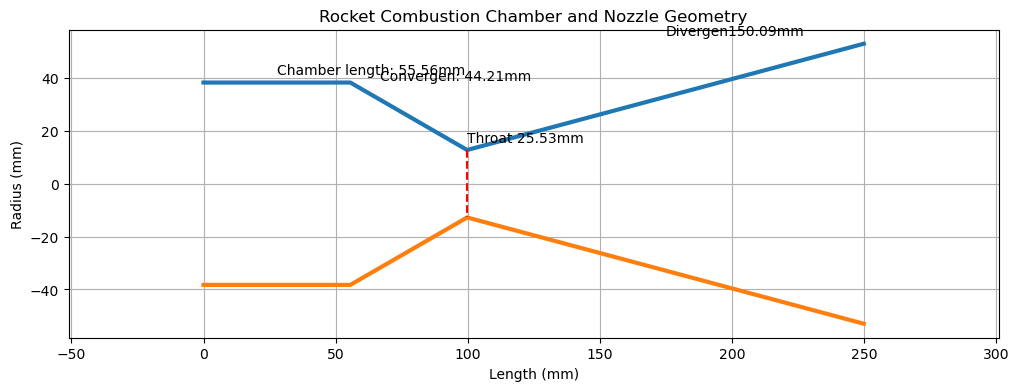

In [24]:
# Convert to radius 
rc = cd_mm / 2
rt = dt_mm / 2
re = de_mm / 2

# X positions
x0 = 0
x1 = lc_mm
x2 = x1 + conv_mm
x3 = x2 + div_mm

#  Upper wall profile 
x_upper = [x0, x1, x2, x3]
y_upper = [rc, rc, rt, re]

# Lower wall profile (mirror)
y_lower = [-y for y in y_upper]

#  Plot 
plt.figure(figsize=(12,4))

plt.plot(x_upper, y_upper, linewidth=3)
plt.plot(x_upper, y_lower, linewidth=3)

# throat marker
plt.plot([x2,x2],[rt,-rt],'r--')

plt.title("Rocket Combustion Chamber and Nozzle Geometry")
plt.xlabel("Length (mm)")
plt.ylabel("Radius (mm)")
plt.axis("equal")
plt.grid(True)

# Labels
plt.text(lc_mm/2, rc+3, f"Chamber length: {lc_mm:.2f}mm")
plt.text(x1+conv_mm/4, rc+1, f"Convergen: {conv_mm:.2f}mm")
plt.text(x2, rt+3, f"Throat {dt_mm:.2f}mm")
plt.text(x2+div_mm/2, re+3,f"Divergen{div_mm:.2f}mm")

plt.show()


In [25]:
# get  Atmosphera Datas from atmosphera_data.py file
importlib.reload(at_data)

altitude = 10 #km

alt = altitude*1000
t, p, rho, h = at_data.get_atmosphere_data(alt)

temp_k = t + 273.15
pressure_pa = p * 1000
pressure_mpa = pressure_pa / 1e6

print(f"Altitude   : {h} m")
print(f"Temperature: {t:.2f} °C")
print(f"Temperature: {temp_k:.2f} K")
print(f"Pressure   : {p:.2f} kPa")
print(f"Pressure   : {pressure_pa:.2f} Pa")
print(f"Pressure   : {pressure_mpa:.6f} MPa")
print(f"Density    : {rho:.4f} kg/m³")

Altitude   : 10000 m
Temperature: -49.86 °C
Temperature: 223.29 K
Pressure   : 26.52 kPa
Pressure   : 26516.21 Pa
Pressure   : 0.026516 MPa
Density    : 0.4140 kg/m³


## Nozzle Flow & Performance Analysis
#### *Analytical Framework for Isentropic Expansion*



### 1. Mach & Area Relations
*Determines the expansion state based on pressure ratios and nozzle geometry.*

| Parameter | Formula | Description |
| :--- | :--- | :--- |
| **Exit Mach ($M_e$)** | $$M_e = \sqrt{\frac{2}{\gamma - 1} \left[\left(\frac{P_c}{P_e}\right)^{\frac{\gamma - 1}{\gamma}} - 1\right]}$$ | Mach number at the exit plane. |
| **Area Ratio ($\epsilon$)** | $$\frac{A_e}{A_t} = \left(\frac{\gamma+1}{2}\right)^{-\frac{\gamma+1}{2(\gamma-1)}} \cdot \frac{\left(1 + \frac{\gamma-1}{2} M_e^2\right)^{\frac{\gamma+1}{2(\gamma-1)}}}{M_e}$$ | Ratio of exit area to throat area. |



###  2. Mass Flow Rates ($\dot{m}$)
*Calculates the rate of propellant consumption through the nozzle.*

* **General Flow:** $$\dot{m}_g = \frac{A_t P_c}{\sqrt{T_c}} \sqrt{\frac{\gamma}{R}} \cdot \left[M_e \left(1 + \frac{\gamma - 1}{2} M_e^2\right)^{-\frac{\gamma + 1}{2(\gamma - 1)}}\right]$$
* **Choked Flow:** $$\dot{m}_c = \frac{A_t P_c}{\sqrt{T_c}} \sqrt{\frac{\gamma}{R}} \cdot \left(\frac{\gamma + 1}{2}\right)^{-\frac{\gamma + 1}{2(\gamma - 1)}}$$
* **Continuity Equation:** $$\dot{m} = \rho_t \cdot V_t \cdot A_t$$



###  3. Thermodynamic Properties
*State variables at the stagnation (chamber) and sonic (throat) points.*

| Location | Quantity | Formula |
| :--- | :--- | :--- |
| **Chamber** | **Stagnation Density** | $$\rho_0 = \frac{P_c}{R T_c}$$ |
| **Throat** | **Velocity ($V_t$)** | $$V_t = \sqrt{\frac{2 \gamma R T_c}{\gamma + 1}}$$ |
| **Throat** | **Density ($\rho_t$)** | $$\rho_t = \rho_0 \left(\frac{2}{\gamma+1}\right)^{\frac{1}{\gamma-1}}$$ |



###  4. Exit Plane Properties
*Conditions of the exhaust gas as it leaves the nozzle.*

* **Exit Pressure ($P_e$):**
    $$P_e = P_c \left(1 + \frac{\gamma - 1}{2} M_e^2\right)^{-\frac{\gamma}{\gamma-1}}$$
* **Exit Temperature ($T_e$):**
    $$T_e = T_c \left(1 + \frac{\gamma - 1}{2} M_e^2\right)^{-1}$$
* **Exit Velocity ($V_e$):**
    $$V_e = M_e \sqrt{\gamma R T_e}$$


###  5. Performance Metrics
*The final output efficiency and power of the motor.*

* **Total Thrust ($F$):**
$$F = \dot{m} V_e + (P_e - P_a) A_e$$
*Where $P_a$ is the ambient atmospheric pressure.*

* **Specific Impulse ($I_{sp}$):**
$$I_{sp} = \frac{V_e}{g}$$

In [26]:
# Envinomental values
pa = pressure_pa  
ta = temp_k        

#Throat Radius
Trs = 3.6837
tr = (2*Trs)/1000

#Exit Radius
Er = 0.0807
er = (Er*2)/1000

#outside air pressure and tempreture
p = 24.5
t = 245

# Exit Mach
me = np.sqrt((2/(y-1))*((pc/pe)**((y-1)/y)-1))
print(f"Exit Mach number: {me:.2f}")

# ratio of area
Ar = ((y+1)/2)**(- (y+1)/(2 * (y-1))) * (((1 + ((y-1)/2) * me**2)**((y+1)/(2 * (y-1)))) / me)
print(f"Ratio of area   :{Ar}")


# Nozzle area ratio
ar = ae/at
print(f"Nozzle area ratio   :{ar}")

# Stagnation Density
ρ0 = pc / (r * tc)
print(f"Stagnation Density  :{ρ0:.2f} kg/m^3")

# Throart Velocity (where mach = 1)
vt = np.sqrt( (2*y*r*tc) / (y+1) )
print(f"Throart Velocity    :{vt:.2f} m/s")

# Throat Density
ρt = ρ0 * (2/(y+1))**(1/(y-1))
print(f"Throat density      :{ρt:.2f} kg/m^3")

#Exit Pressure
ep = pc * (1+((y-1)/2)*(me**2))**(-(y/(y-1)))
print(f"Exit Pressure       :{ep:.2f} pa")

# Exit Tempreture
et = tc * (1 + (((y-1)/2) * (me**2)))**-1
print(f"Exit Tempreture     :{et:.2f} K")

# Exit Vlecity 
v_e = np.sqrt(y * r * et) * me
print(f"EXit velocity       :{v_e:.2f} m/s")

# General mass flow rate (check)
mg = ((at * pc) / np.sqrt(tc)) * np.sqrt(y / r) * (
     me * (1 + ((y - 1) / 2) * me**2)**(-(y + 1) / (2 * (y - 1))))
print(f"General mass flow rate: {mg:.4f} kg/s")

# Choked mass flow rate:
mc = ((at * pc) / np.sqrt(tc)) * (np.sqrt(y / r)) * (
     ((y + 1) / 2)**(-((y + 1) / (2 * (y - 1)))))
print(f"Choked mass flow rate: {mc:.4f} kg/s")

#Exit Mass flow

#m0 = ρt * vt * at 
m0 = (pc * at / np.sqrt(tc)) * (np.sqrt(y / r) ) * (2 / (y + 1))**((y + 1) / (2 * (y - 1)))
print(f"Mass flow rate : {m0:.4f} kg/s")

#FORCE
F = m0 * v_e + (ep - pa) * ae
print(f"Thrust Final        :{F:.2f} N")

isp = v_e / g
print(f"specific impluse    :{isp} S")


Exit Mach number: 3.73
Ratio of area   :17.231072604191667
Nozzle area ratio   :17.231072604191667
Stagnation Density  :2.96 kg/m^3
Throart Velocity    :1135.36 m/s
Throat density      :1.84 kg/m^3
Exit Pressure       :20000.00 pa
Exit Tempreture     :1302.42 K
EXit velocity       :2806.04 m/s
General mass flow rate: 0.0620 kg/s
Choked mass flow rate: 1.0691 kg/s
Mass flow rate : 1.0691 kg/s
Thrust Final        :2942.54 N
specific impluse    :286.13680377354603 S


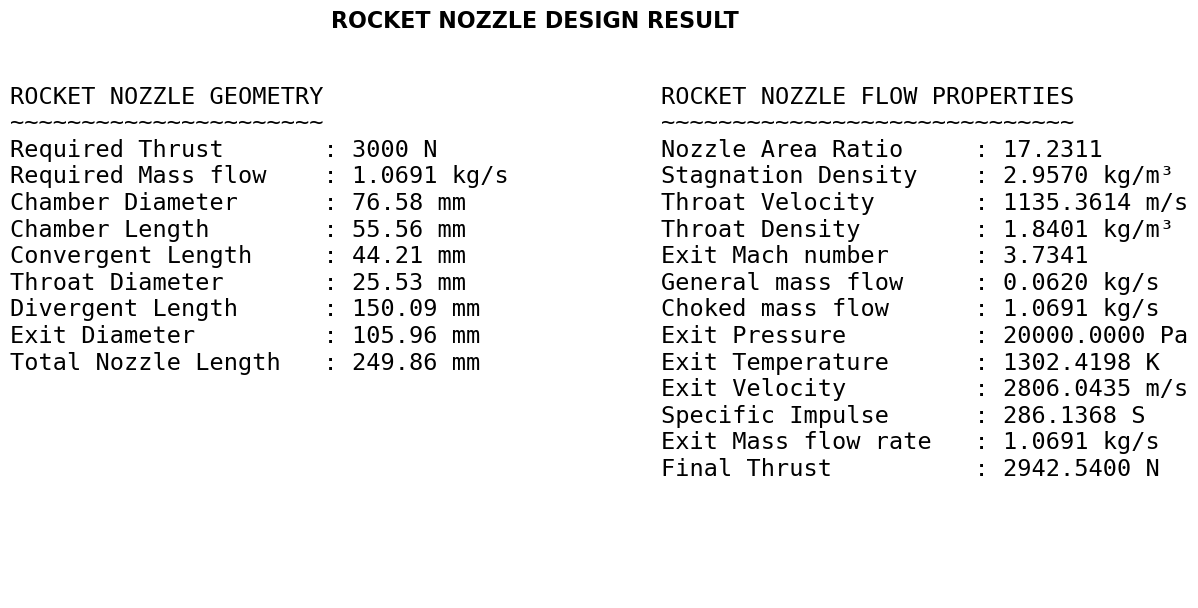

In [27]:
# Geometry report
geometry_report = f"""
ROCKET NOZZLE GEOMETRY
~~~~~~~~~~~~~~~~~~~~~~
Required Thrust       : {f} N
Required Mass flow    : {m:.4f} kg/s
Chamber Diameter      : {cd_mm:.2f} mm
Chamber Length        : {lc_mm:.2f} mm
Convergent Length     : {conv_mm:.2f} mm
Throat Diameter       : {dt_mm:.2f} mm
Divergent Length      : {div_mm:.2f} mm
Exit Diameter         : {de_mm:.2f} mm
Total Nozzle Length   : {total_mm:.2f} mm
"""

# Flow report
flow_report = f"""
ROCKET NOZZLE FLOW PROPERTIES
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Nozzle Area Ratio     : {ar:.4f} 
Stagnation Density    : {ρ0:.4f} kg/m³
Throat Velocity       : {vt:.4f} m/s
Throat Density        : {ρt:.4f} kg/m³
Exit Mach number      : {me:.4f}
General mass flow     : {mg:.4f} kg/s
Choked mass flow      : {mc:.4f} kg/s
Exit Pressure         : {ep:.4f} Pa
Exit Temperature      : {et:.4f} K
Exit Velocity         : {v_e:.4f} m/s
Specific Impulse      : {isp:.4f} S
Exit Mass flow rate   : {m0:.4f} kg/s
Final Thrust          : {F:.4f} N
""" 

# Create figure
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
plt.subplots_adjust(wspace=0.5)

# Left panel
ax[0].axis("off")
ax[0].text(0, 1, geometry_report, fontsize=17,va='top', family='monospace')

# Right panel
ax[1].axis("off")  
ax[1].text(0, 1, flow_report, fontsize=17, va='top', family='monospace')

# Add main title
fig.suptitle("ROCKET NOZZLE DESIGN RESULT", fontsize=16, fontweight='bold', y=0.95)


plt.show()

##  Bell Nozzle Geometry (Rao Method)



###  1. Geometric Constants & Point N
| Quantity | Formula | Quantity | Formula |
| :--- | :--- | :--- | :--- |
| **Throat Radius** | $r_t = d_t / 2$ | **Expansion Ratio** | $\epsilon = A_e / A_t$ |
| **Exit Radius** | $r_e = d_e / 2$ | **Throat Arc $R_1$** | $R_1 = 0.382 \, r_t$ |
| **X-Coord at N** | $x_n = R_1 \sin \theta_n$ | **Y-Coord at N** | $y_n = r_t + R_1 (1 - \cos \theta_n)$ |



###  2. Convergent & Bell Angles
| Quantity | Formula | Quantity | Formula |
| :--- | :--- | :--- | :--- |
| **Conv. Angle $\theta$** | $25^\circ$ | **Arc Radius $R_c$** | $1.5 \, r_t$ |
| **Start Angle $\theta_n$** | $30^\circ$ | **Arc End Rad $r_n$** | $r_t + R_c (1 - \cos \theta)$ |
| **Exit Angle $\theta_e$** | $8.5^\circ$ | **Arc Length $l_1$** | $R_c \sin \theta$ |
| **Conical Length $l_n$** | $\frac{r_t(\sqrt{\epsilon}-1) + R_c(\cos\theta - 1)}{\tan\theta}$ | **Fractional Len $f$** | *User Defined (e.g. 0.8)* |


### 3. Core Design Equations
**Nozzle Length (Rao Approximation):**
$$\displaystyle L = f \cdot \frac{r_t}{\tan(15^\circ)} \left[ \sqrt{\epsilon - 1} + 1.5 \left(\frac{1}{\cos(15^\circ)} - 1\right) \right]$$

**Parabolic Bell Contour Equation:**
$$\displaystyle r(x) = y_n + \tan(\theta_n)(x - x_n) + \frac{\tan(\theta_e) - \tan(\theta_n)}{2(L - x_n)} (x - x_n)^2$$



###  4. Boundary Conditions
| Condition | Formula | Condition | Formula |
| :--- | :--- | :--- | :--- |
| **Radius at N** | $r(x_n) = y_n$ | **Slope at N** | $\displaystyle \left.\frac{dr}{dx}\right\|_{x_n} = \tan(\theta_n)$ |
| **Radius at Exit** | $r(L) = r_e$ | **Slope at Exit** | $\displaystyle \left.\frac{dr}{dx}\right\|_{L} = \tan(\theta_e)$ |

--- CONICAL / CONVERGENT DATA ---
r1 = 19.144569499174363
cl = 55.55555555555557
cr = 38.289138998348726
covergen length = 36.12164473195619
e = 17231.072604191668
rt = 12.76304633278291
re = 52.97982287534887
l1 = 8.090844683515082
Re = 52.97982287534888
rn = 14.55674341539121
ln = 82.39855980916789

---- BELL BOUNDARY CHECK ----
At N (radius)      : 0.013416237292728474
At Exit (radius)   : 0.06905243462067803 Expected: 0.05297982287534887
Slope at N         : 0.5773502691896257 Expected: 0.5773502691896257
Slope at Exit      : 0.1494510013491278 Expected: 0.1494510013491278
LENGTH (Rao method) :155.53653125236016


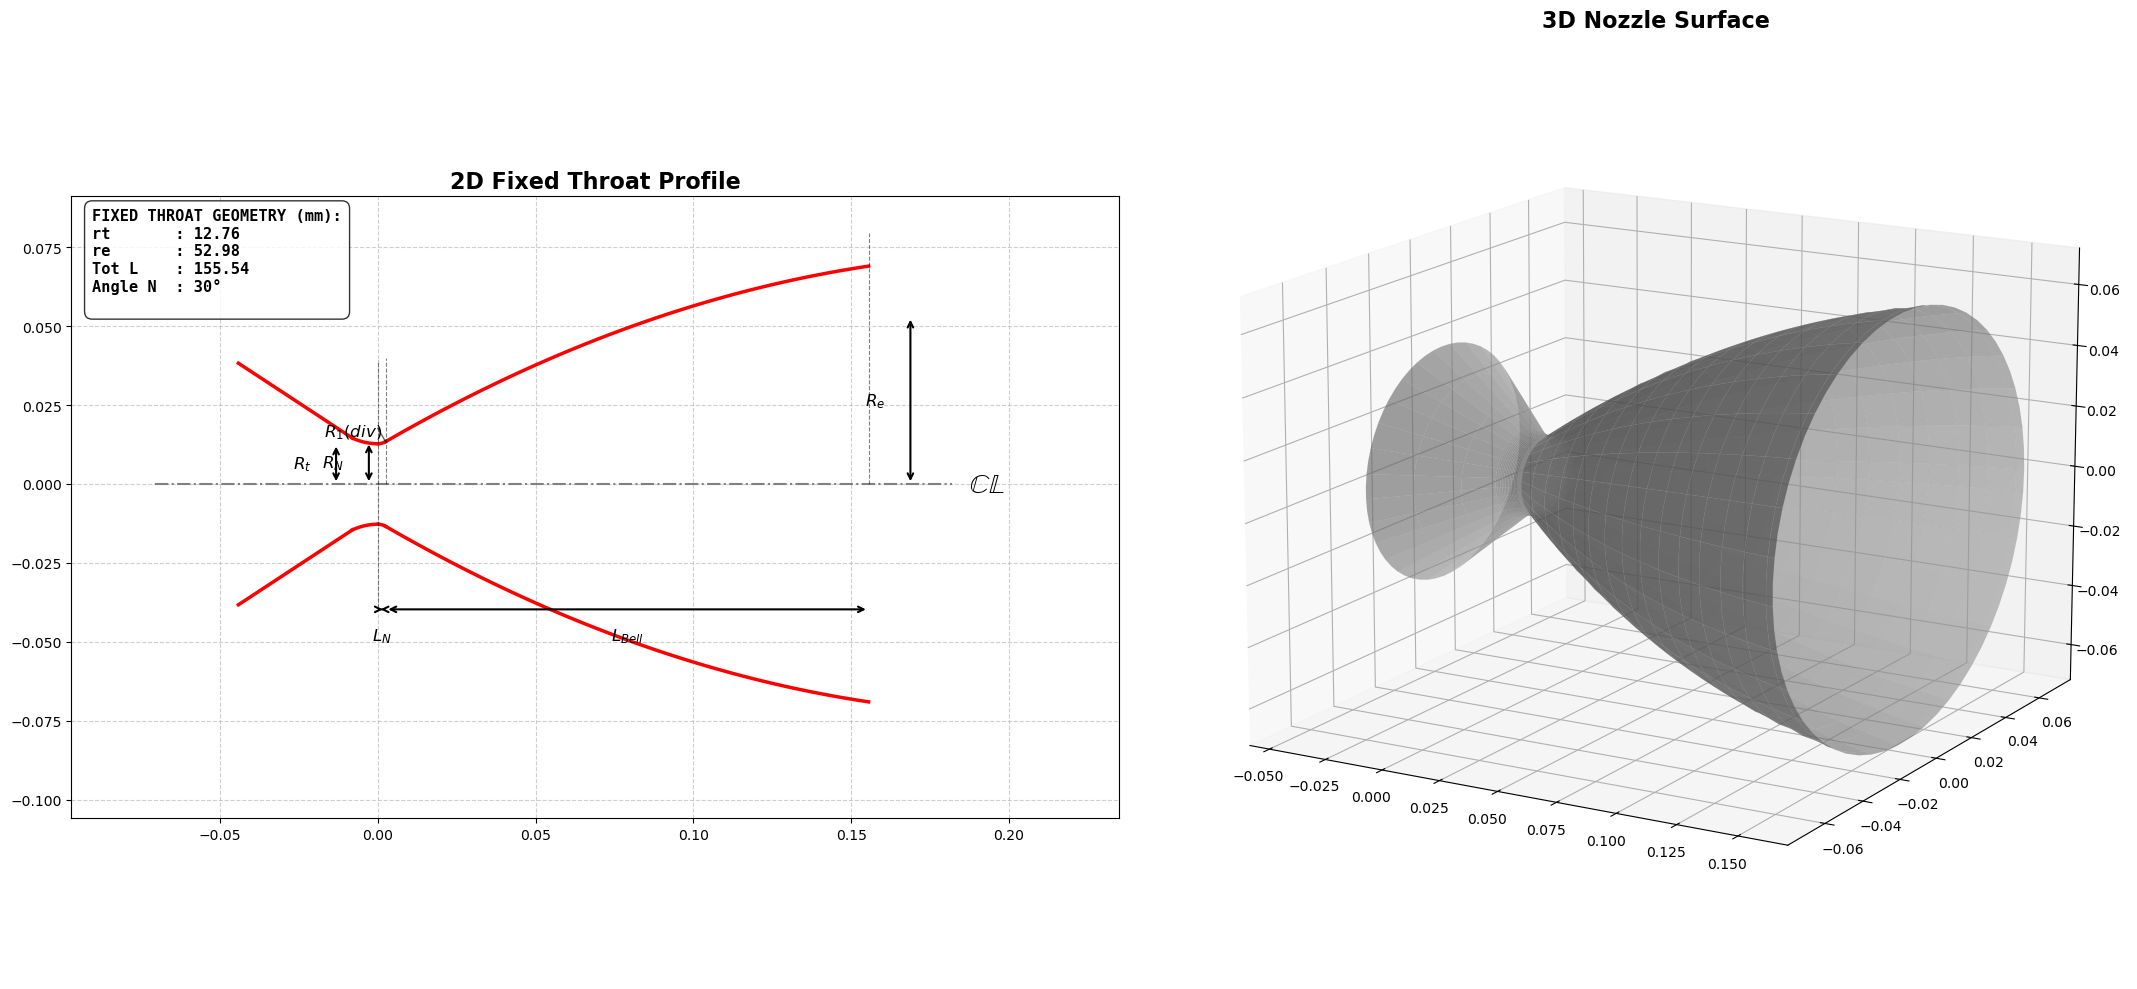

In [42]:
                                #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~BELL NOZZLE GEOMETRY~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#
# CONVERGENT & CONICAL SETUP CALCULATIONS

rt = dt / 2   #throat dia
re = de / 2   #exit dia
e = ae / at

throat_angle = 25
theta = np.radians(throat_angle) 

r1 = 1.5 * rt
Re = np.sqrt(e) * rt
rn = rt + r1 * (1 - np.cos(theta))

# arc length
l1 = r1 * np.sin(theta)

# CONVERTING MILLIMETERS TO METERS FOR PLOTTING
cl = lc_mm / 1000              # Chamber length converted to meters
cr = (cd_mm / 2) / 1000        # Chamber radius converted to meters
con_l = (conv_mm / 1000) - l1  # Convergent length converted to meters

# conical length
ln = (rt * (np.sqrt(e) - 1) + r1 * (np.cos(theta) - 1)) / np.tan(theta)

print("--- CONICAL / CONVERGENT DATA ---")
print("r1 =", r1 * 1000)
print("cl =", cl * 1000)
print("cr =", cr * 1000)
print("covergen length =", con_l * 1000)
print("e =", e * 1000)
print("rt =", rt * 1000)
print("re =", re * 1000)
print("l1 =", l1 * 1000)
print("Re =", Re * 1000)
print("rn =", rn * 1000)
print("ln =", ln * 1000)


# BELL NOZZLE DESIGN (AFTER N POINT)

# OVERWRITING r1 for the Bell throat downstream radius
r1 = 0.382 * rt

# Slop Angles
θn = 30
θe = 8.5

# angles (convert to radians)
tita_n = np.radians(θn)
tita_e = np.radians(θe)

# Point N
xn = r1 * np.sin(tita_n)
yn = rt + r1 * (1 - np.cos(tita_n))

# LENGTH (Rao method) 
f = 0.8   # length factor (60%–80%)
l = f * (rt / np.tan(np.radians(15))) * (
        np.sqrt(e - 1) + 1.5 * ((1 / np.cos(np.radians(15))) - 1))

# ---- PARABOLIC BELL EQUATION ----
# r(x) from Rao
x = np.linspace(xn, l, 100)
rx = yn + np.tan(tita_n) * (x - xn) \
         + ((np.tan(tita_e) - np.tan(tita_n)) / (2 * (l - xn))) * (x - xn)**2

# 4 BOUNDARY CONDITION CHECKS
r_start = yn
r_exit = yn + np.tan(tita_n) * (l - xn) \
             + ((np.tan(tita_e) - np.tan(tita_n)) / (2 * (l - xn))) * (l - xn)**2
slope_N = np.tan(tita_n)
slope_exit = np.tan(tita_n) + \
                 ((np.tan(tita_e) - np.tan(tita_n)) / (l - xn)) * (l - xn)

print("\n---- BELL BOUNDARY CHECK ----")
print("At N (radius)      :", r_start)
print("At Exit (radius)   :", r_exit, "Expected:", re)
print("Slope at N         :", slope_N, "Expected:", np.tan(tita_n))
print("Slope at Exit      :", slope_exit, "Expected:", np.tan(tita_e))
print(f"LENGTH (Rao method) :{l*1000}")



# ploting the graph
fig = plt.figure(figsize=(22, 10)) 

# --- 2D PLOT  ---
ax1 = fig.add_subplot(121)
ax1.set_aspect('equal', adjustable='box')
ax1.grid(True, linestyle='--', alpha=0.6) 

pad = Re * 0.5

# PRESERVED CONVERGENT GEOMETRY
r1_conv = 1.5 * rt
l1_conv = r1_conv * np.sin(theta)
y_conv_end = rt + r1_conv * (1 - np.cos(theta))

# Geometry anchors
x_chamber_end = -(con_l + l1_conv)
x_conv_end = -l1_conv

# CORRECTED ARC RADIANS: Ensuring they meet perfectly at x=0
# Convergent Arc: ends exactly at -90 degrees (x=0)
t_vals_conv = np.linspace(-np.pi/2 - theta, -np.pi/2, 100)
# Divergent Arc: starts exactly at -90 degrees (x=0)
t_vals_div = np.linspace(-np.pi/2, -np.pi/2 + tita_n, 100)

def plot_nozzle_side(sign=1):
    # --- CONVERGENT SECTION  ---
    # 2. Convergent Wall
    ax1.plot([x_chamber_end, x_conv_end], [sign*cr, sign*y_conv_end], 'r-', linewidth=2.5)
    
    # 3. Convergent Arc - Center is at x=0, y=sign*(rt + r1_conv)
    ax1.plot(r1_conv * np.cos(t_vals_conv), sign*(r1_conv * np.sin(t_vals_conv) + (rt + r1_conv)), 'r-', linewidth=2.5)
    
    # --- DIVERGENT SECTION ---
    # 4. Divergent Arc (Throat to N) - Center is at x=0, y=sign*(rt + r1)
    ax1.plot(r1 * np.cos(t_vals_div), sign*(r1 * np.sin(t_vals_div) + (rt + r1)), 'r-', linewidth=2.5)
    
    # 5. Bell Curve (N to Exit) 
    bell_mask = x >= xn
    ax1.plot(x[bell_mask], sign*rx[bell_mask], 'r-', linewidth=2.5)

# Plot top and bottom on 2D axis
plot_nozzle_side(sign=1)
plot_nozzle_side(sign=-1)

# CENTERLINE
ax1.plot([x_chamber_end - pad, l + pad], [0, 0], color='gray', linestyle='-.', linewidth=1.5)
ax1.text(l + pad*1.2, 0, r'$\mathbb{CL}$', fontsize=20, fontweight='bold', va='center')

# CONSTRUCTION LINES
ax1.plot([0, 0], [-(rt+pad), rt+pad], 'k--', linewidth=0.8, alpha=0.5)  # Throat
ax1.plot([xn, xn], [0, yn + pad], 'k--', linewidth=0.8, alpha=0.5)      # Point N
ax1.plot([l, l], [0, Re + pad], 'k--', linewidth=0.8, alpha=0.5)        # Exit

# Radius Construction for R1 
ax1.plot([0, xn], [rt + r1, yn], 'k-', linewidth=1, alpha=0.6)
ax1.text(xn/2, rt + r1/2, r'$R_1 (div)$', fontsize=12, ha='right')

# DIMENSIONING
def draw_dim(x1, y1, x2, y2, text, color='black', off=0):
    ax1.annotate('', xy=(x1, y1), xytext=(x2, y2), arrowprops=dict(arrowstyle='<->', color=color, lw=1.5))
    if x1 == x2: 
        ax1.text(x1 - pad*0.3, (y1+y2)/2, text, color=color, fontsize=12, va='center', ha='right', fontweight='bold')
    else: 
        ax1.text((x1+x2)/2, y1 - off, text, color=color, fontsize=12, ha='center', va='top', fontweight='bold')

draw_dim(-pad*0.5, 0, -pad*0.5, rt, r'$R_t$')
draw_dim(xn - pad*0.2, 0, xn - pad*0.2, yn, r'$R_N$')
draw_dim(l + pad*0.5, 0, l + pad*0.5, Re, r'$R_e$')
draw_dim(0, -pad*1.5, xn, -pad*1.5, r'$L_N$', off=pad*0.2)
draw_dim(xn, -pad*1.5, l, -pad*1.5, r'$L_{Bell}$', off=pad*0.2)

# DATA SUMMARY TABLE
stats_text = (
    f"FIXED THROAT GEOMETRY (mm):\n"
    f"rt       : {rt*1000:.2f} \n"
    f"re       : {re*1000:.2f} \n"
    f"Tot L    : {l*1000:.2f} \n"
    f"Angle N  : {θn}°\n"
)
ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, fontsize=11,
        verticalalignment='top', family='monospace', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8))

ax1.set_xlim(x_chamber_end - pad*2, l + pad*3)
ax1.set_ylim(-(Re + pad*2), max(cr, rt + r1_conv) + pad*2)
ax1.set_title("2D Fixed Throat Profile", fontsize=16, fontweight='bold')

#  3D PLOT 
ax2 = fig.add_subplot(122, projection='3d')

# Generate arrays for 3D rotation
x_conv_wall_arr = np.linspace(x_chamber_end, x_conv_end, 20)
y_conv_wall_arr = np.linspace(cr, y_conv_end, 20)

x_conv_arc_arr = r1_conv * np.cos(t_vals_conv)
y_conv_arc_arr = r1_conv * np.sin(t_vals_conv) + (rt + r1_conv)

x_div_arc_arr = r1 * np.cos(t_vals_div)
y_div_arc_arr = r1 * np.sin(t_vals_div) + (rt + r1)


X_full = np.concatenate([x_conv_wall_arr, x_conv_arc_arr, x_div_arc_arr[1:], x[x > xn]])
Y_full = np.concatenate([y_conv_wall_arr, y_conv_arc_arr, y_div_arc_arr[1:], rx[x > xn]])

Theta_rot = np.linspace(0, 2*np.pi, 60)
X_mesh, T_mesh = np.meshgrid(X_full, Theta_rot)
Y_mesh = Y_full * np.cos(T_mesh)
Z_mesh = Y_full * np.sin(T_mesh)

ax2.plot_surface(X_mesh, Y_mesh, Z_mesh, color='darkgray', alpha=0.6, 
                 edgecolor='darkgray', linewidth=0.1)

ax2.set_title("3D Nozzle Surface", fontsize=16, fontweight='bold')
ax2.view_init(elev=15, azim=-60)

plt.tight_layout()
plt.show()

r1 = 19.144569499174363
cl = 55.55555555555557
cr = 38.289138998348726
covergen length = 38.61515899481475
e = 17231.072604191668
rt = 12.76304633278291
re = 52.97982287534887
l1 = 5.59733042065652
Re = 52.97982287534888
rn = 13.59957296903196
ln = 128.80699352263653
Total length = 134.40432394329304


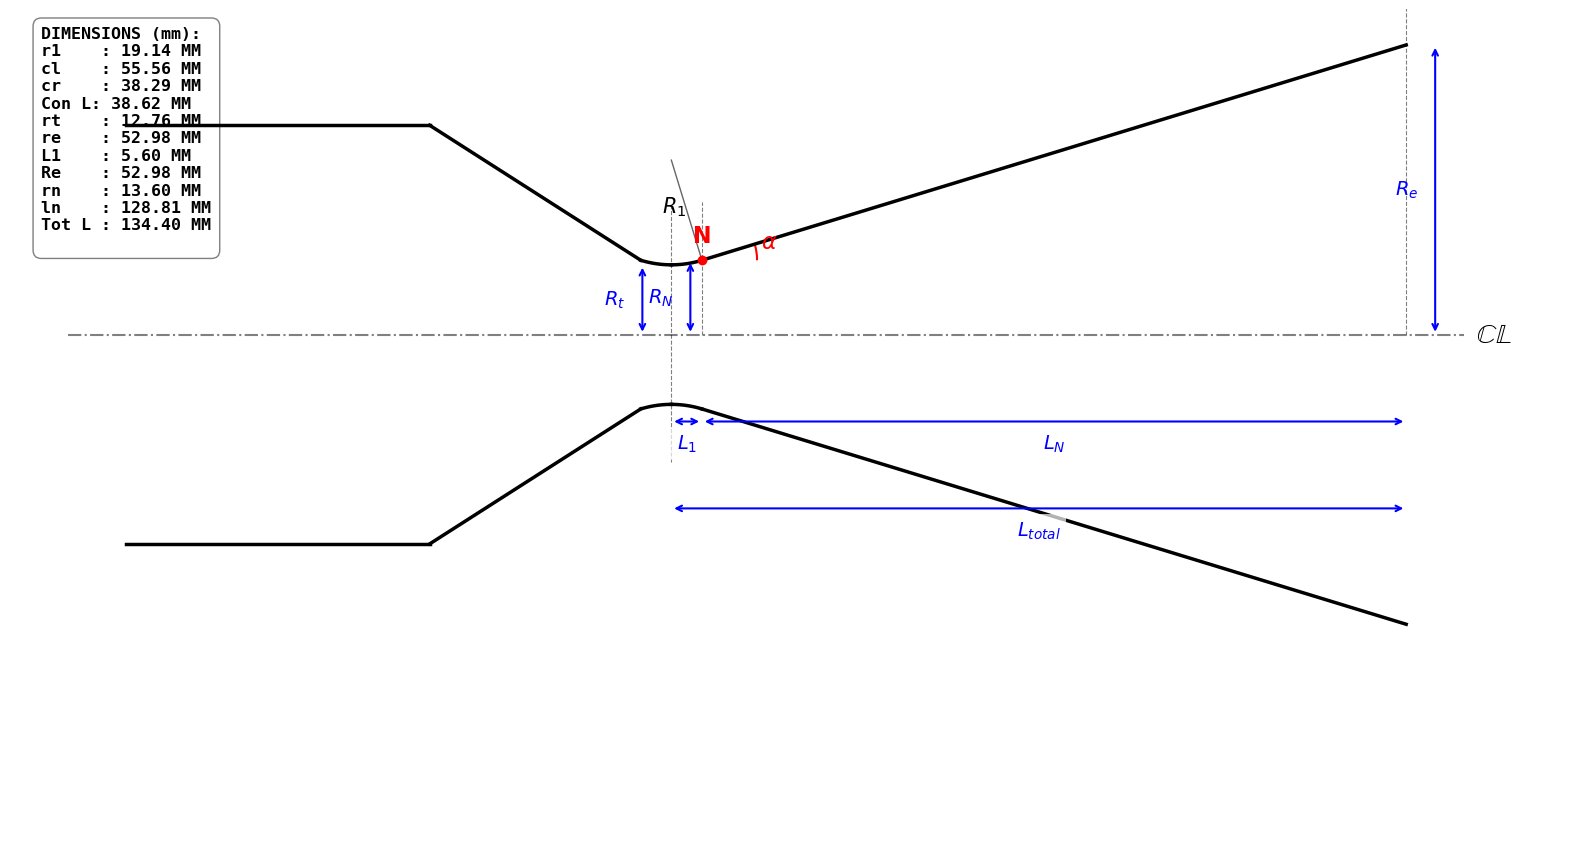

In [39]:
     #Conical Nozzles

rt = dt / 2
re = de / 2 
e = ae / at

throat_angle = 17

theta = np.radians(throat_angle) 

r1 = 1.5 * rt
Re = np.sqrt(e) * rt
rn = rt + r1 * (1 - np.cos(theta))

# arc length
l1 = r1 * np.sin(theta)


# CONVERTING MILLIMETERS TO METERS FOR PLOTTING
cl = lc_mm / 1000              # Chamber length converted to meters
cr = (cd_mm / 2) / 1000        # Chamber radius converted to meters
con_l = (conv_mm / 1000) - l1  # Convergent length converted to meters

# conical length
ln = (rt * (np.sqrt(e) - 1) + r1 * (np.cos(theta) - 1)) / np.tan(theta)

# total length
l = l1 + ln

print("r1 =", r1 * 1000)
print("cl =", cl * 1000)
print("cr =", cr * 1000)
print("covergen length =", con_l * 1000)
print("e =", e * 1000)
print("rt =", rt * 1000)
print("re =", re * 1000)
print("l1 =", l1 * 1000)
print("Re =", Re * 1000)
print("rn =", rn * 1000)
print("ln =", ln * 1000)
print("Total length =", l * 1000)


# --- PLOTTING CODE ---
fig, ax = plt.subplots(figsize=(16, 10)) 

ax.set_aspect('equal', adjustable='box')
ax.axis('off') 

pad = Re * 0.2

# GEOMETRY CALCULATIONS
x_chamber_start = -(cl + con_l + l1)
x_chamber_end = -(con_l + l1)
x_conv_end = -l1
y_conv_end = rt + r1 * (1 - np.cos(theta))

def plot_nozzle_side(sign=1):
    ax.plot([x_chamber_start, x_chamber_end], [sign*cr, sign*cr], 'k-', linewidth=2.5)
    ax.plot([x_chamber_end, x_conv_end], [sign*cr, sign*y_conv_end], 'k-', linewidth=2.5)
    t_vals_conv = np.linspace(-np.pi/2 - theta, -np.pi/2, 100)
    ax.plot(r1 * np.cos(t_vals_conv), sign*(r1 * np.sin(t_vals_conv) + (rt + r1)), 'k-', linewidth=2.5)
    t_vals = np.linspace(-np.pi/2, -np.pi/2 + theta, 100)
    ax.plot(r1 * np.cos(t_vals), sign*(r1 * np.sin(t_vals) + (rt + r1)), 'k-', linewidth=2.5)
    ax.plot([l1, l], [sign*rn, sign*Re], 'k-', linewidth=2.5)

plot_nozzle_side(sign=1)
plot_nozzle_side(sign=-1)

ax.plot([x_chamber_start - pad, l + pad], [0, 0], color='gray', linestyle='-.', linewidth=1.5)
ax.text(l + pad*1.2, 0, r'$\mathbb{CL}$', fontsize=20, fontweight='bold', va='center')

# CONSTRUCTION LINES
ax.plot([0, 0], [-(rt+pad), rt+pad], 'k--', linewidth=0.8, alpha=0.5) 
ax.plot([l1, l1], [0, rn + pad], 'k--', linewidth=0.8, alpha=0.5)      
ax.plot([l, l], [0, Re + pad], 'k--', linewidth=0.8, alpha=0.5)        

ax.plot([0, l1], [rt + r1, rn], 'k-', linewidth=1, alpha=0.6)
ax.text(l1/2, rt + r1/2, r'$R_1$', fontsize=15, ha='right')

arc_alpha = patches.Arc((l1, rn), l*0.15, l*0.15, theta1=0, theta2=np.degrees(theta), color='red', linewidth=1.5)
ax.add_patch(arc_alpha)
ax.text(l1 + l*0.08, rn + pad*0.2, r'$\alpha$', fontsize=16, color='red', fontweight='bold')

def draw_dim(x1, y1, x2, y2, text, color='blue', off=0):
    ax.annotate('', xy=(x1, y1), xytext=(x2, y2), arrowprops=dict(arrowstyle='<->', color=color, lw=1.5))
    if x1 == x2: 
        ax.text(x1 - pad*0.3, (y1+y2)/2, text, color=color, fontsize=14, va='center', ha='right', fontweight='bold')
    else: 
        ax.text((x1+x2)/2, y1 - off, text, color=color, fontsize=14, ha='center', va='top', fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

draw_dim(-pad*0.5, 0, -pad*0.5, rt, r'$R_t$')
draw_dim(l1 - pad*0.2, 0, l1 - pad*0.2, rn, r'$R_N$')
draw_dim(l + pad*0.5, 0, l + pad*0.5, Re, r'$R_e$')

draw_dim(0, -pad*1.5, l1, -pad*1.5, r'$L_1$', off=pad*0.2)
draw_dim(l1, -pad*1.5, l, -pad*1.5, r'$L_N$', off=pad*0.2)
draw_dim(0, -pad*3.0, l, -pad*3.0, r'$L_{total}$', off=pad*0.2)

ax.plot(l1, rn, 'ro', markersize=6)
ax.text(l1, rn + pad*0.3, 'N', color='red', fontsize=16, fontweight='bold', ha='center')


# DATA SUMMARY TABLE ON THE DIAGRAM
stats_text = (
    f"DIMENSIONS (mm):\n"
    f"r1    : {r1*1000:.2f} MM\n"
    f"cl    : {cl*1000:.2f} MM\n"
    f"cr    : {cr*1000:.2f} MM\n"
    f"Con L: {con_l*1000:.2f} MM\n"
    f"rt    : {rt*1000:.2f} MM\n"
    f"re    : {re*1000:.2f} MM\n"
    f"L1    : {l1*1000:.2f} MM\n"
    f"Re    : {Re*1000:.2f} MM\n"
    f"rn    : {rn*1000:.2f} MM\n"
    f"ln    : {ln*1000:.2f} MM\n"
    f"Tot L : {l*1000:.2f} MM\n"
)

# Place the text box in the upper left corner
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', family='monospace', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='none', edgecolor='black', alpha=0.5))

ax.set_xlim(x_chamber_start - pad*2, l + pad*3)
ax.set_ylim(-(Re + pad*4), max(cr, rt + r1) + pad*2)

plt.tight_layout()
plt.show()

--- CONICAL / CONVERGENT DATA ---
r1 = 19.144569499174363
cl = 55.55555555555557
cr = 38.289138998348726
covergen length = 36.12164473195619
e = 17231.072604191668
rt = 12.76304633278291
re = 52.97982287534887
l1 = 8.090844683515082
Re = 52.97982287534888
rn = 14.55674341539121
ln = 82.39855980916789

---- BELL BOUNDARY CHECK ----
At N (radius)      : 0.013416237292728474
At Exit (radius)   : 0.06905243462067803 Expected: 0.05297982287534887
Slope at N         : 0.5773502691896257 Expected: 0.5773502691896257
Slope at Exit      : 0.1494510013491278 Expected: 0.1494510013491278
LENGTH (Rao method) :155.53653125236016


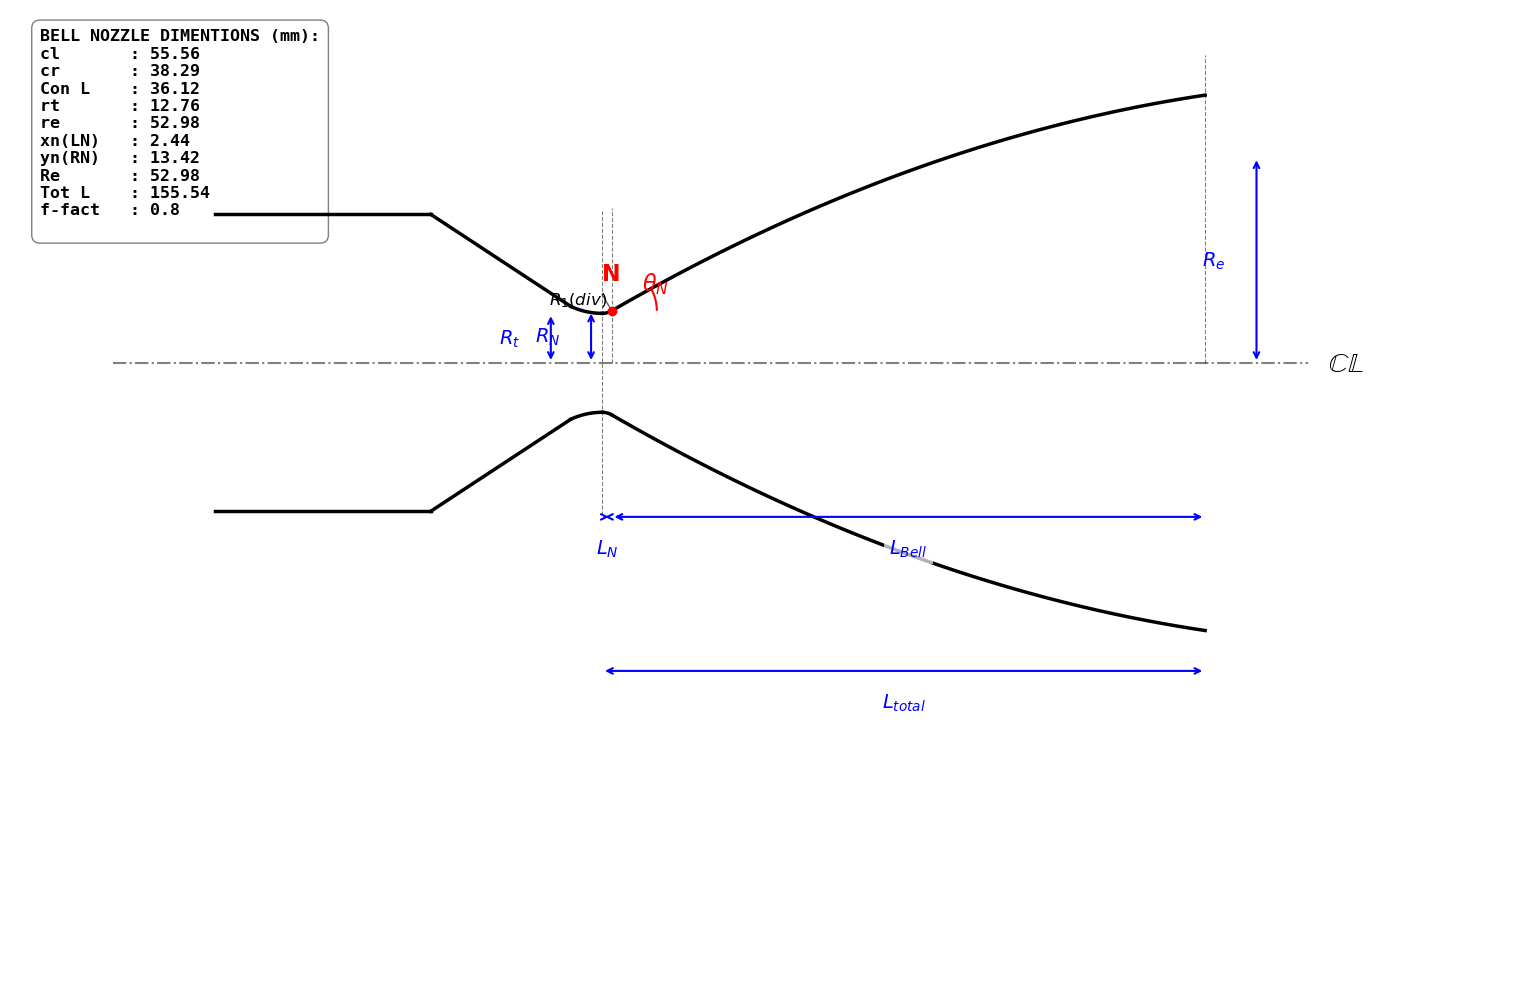

In [40]:
                                #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~BELL NOZZLE GEOMETRY~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~#
# CONVERGENT & CONICAL SETUP CALCULATIONS

rt = dt / 2
re = de / 2 
e = ae / at

throat_angle = 25
theta = np.radians(throat_angle) 

r1 = 1.5 * rt
Re = np.sqrt(e) * rt
rn = rt + r1 * (1 - np.cos(theta))

# arc length
l1 = r1 * np.sin(theta)

# CONVERTING MILLIMETERS TO METERS FOR PLOTTING
cl = lc_mm / 1000              # Chamber length converted to meters
cr = (cd_mm / 2) / 1000        # Chamber radius converted to meters
con_l = (conv_mm / 1000) - l1  # Convergent length converted to meters

# conical length
ln = (rt * (np.sqrt(e) - 1) + r1 * (np.cos(theta) - 1)) / np.tan(theta)

print("--- CONICAL / CONVERGENT DATA ---")
print("r1 =", r1 * 1000)
print("cl =", cl * 1000)
print("cr =", cr * 1000)
print("covergen length =", con_l * 1000)
print("e =", e * 1000)
print("rt =", rt * 1000)
print("re =", re * 1000)
print("l1 =", l1 * 1000)
print("Re =", Re * 1000)
print("rn =", rn * 1000)
print("ln =", ln * 1000)


# BELL NOZZLE DESIGN (AFTER N POINT)

# OVERWRITING r1 for the Bell throat downstream radius
r1 = 0.382 * rt

# Slop Angles
θn = 30
θe = 8.5

# angles (convert to radians)
tita_n = np.radians(θn)
tita_e = np.radians(θe)

# Point N
xn = r1 * np.sin(tita_n)
yn = rt + r1 * (1 - np.cos(tita_n))

# LENGTH (Rao method) 
f = 0.8   # length factor (60%–80%)
l = f * (rt / np.tan(np.radians(15))) * (
        np.sqrt(e - 1) + 1.5 * ((1 / np.cos(np.radians(15))) - 1))

# ---- PARABOLIC BELL EQUATION ----
# r(x) from Rao
x = np.linspace(xn, l, 100)
rx = yn + np.tan(tita_n) * (x - xn) \
         + ((np.tan(tita_e) - np.tan(tita_n)) / (2 * (l - xn))) * (x - xn)**2

# 4 BOUNDARY CONDITION CHECKS
r_start = yn
r_exit = yn + np.tan(tita_n) * (l - xn) \
             + ((np.tan(tita_e) - np.tan(tita_n)) / (2 * (l - xn))) * (l - xn)**2
slope_N = np.tan(tita_n)
slope_exit = np.tan(tita_n) + \
                 ((np.tan(tita_e) - np.tan(tita_n)) / (l - xn)) * (l - xn)

print("\n---- BELL BOUNDARY CHECK ----")
print("At N (radius)      :", r_start)
print("At Exit (radius)   :", r_exit, "Expected:", re)
print("Slope at N         :", slope_N, "Expected:", np.tan(tita_n))
print("Slope at Exit      :", slope_exit, "Expected:", np.tan(tita_e))
print(f"LENGTH (Rao method) :{l*1000}")



# DIAGRAM SHEET PLOTTING

fig, ax = plt.subplots(figsize=(20, 10)) 

ax.set_aspect('equal', adjustable='box')
ax.axis('off') 

pad = Re * 0.5

# PRESERVED CONVERGENT GEOMETRY (Using the 1.5 * rt logic)
r1_conv = 1.5 * rt
l1_conv = r1_conv * np.sin(theta)
y_conv_end = rt + r1_conv * (1 - np.cos(theta))

x_chamber_start = -(cl + con_l + l1_conv)
x_chamber_end = -(con_l + l1_conv)
x_conv_end = -l1_conv

def plot_nozzle_side(sign=1):
    # 1. Chamber
    ax.plot([x_chamber_start, x_chamber_end], [sign*cr, sign*cr], 'k-', linewidth=2.5)
    # 2. Convergent Wall
    ax.plot([x_chamber_end, x_conv_end], [sign*cr, sign*y_conv_end], 'k-', linewidth=2.5)
    # 3. Convergent Arc (uses the 1.5*rt radius)
    t_vals_conv = np.linspace(-np.pi/2 - theta, -np.pi/2, 100)
    ax.plot(r1_conv * np.cos(t_vals_conv), sign*(r1_conv * np.sin(t_vals_conv) + (rt + r1_conv)), 'k-', linewidth=2.5)
    
    # 4. Divergent Arc (Throat to N) - Uses Bell r1 (0.382*rt) & tita_n
    t_vals_div = np.linspace(-np.pi/2, -np.pi/2 + tita_n, 100)
    ax.plot(r1 * np.cos(t_vals_div), sign*(r1 * np.sin(t_vals_div) + (rt + r1)), 'k-', linewidth=2.5)
    
    # 5. Bell Curve (N to Exit) - Uses Rao Parabolic array
    ax.plot(x, sign*rx, 'k-', linewidth=2.5)

# Plot top and bottom
plot_nozzle_side(sign=1)
plot_nozzle_side(sign=-1)

# CENTERLINE
ax.plot([x_chamber_start - pad, l + pad], [0, 0], color='gray', linestyle='-.', linewidth=1.5)
ax.text(l + pad*1.2, 0, r'$\mathbb{CL}$', fontsize=20, fontweight='bold', va='center')

# CONSTRUCTION LINES (Updated to use xn, yn for Point N)
ax.plot([0, 0], [-(rt+pad), rt+pad], 'k--', linewidth=0.8, alpha=0.5)  # Throat
ax.plot([xn, xn], [0, yn + pad], 'k--', linewidth=0.8, alpha=0.5)      # Point N
ax.plot([l, l], [0, Re + pad], 'k--', linewidth=0.8, alpha=0.5)        # Exit

# Radius Construction for R1 (Bell downstream)
ax.plot([0, xn], [rt + r1, yn], 'k-', linewidth=1, alpha=0.6)
ax.text(xn/2, rt + r1/2, r'$R_1 (div)$', fontsize=12, ha='right')

# ANGLE LABEL for Theta_N
arc_alpha = patches.Arc((xn, yn), l*0.15, l*0.15, theta1=0, theta2=np.degrees(tita_n), color='red', linewidth=1.5)
ax.add_patch(arc_alpha)
ax.text(xn + l*0.05, yn + pad*0.2, r'$\theta_N$', fontsize=16, color='red', fontweight='bold')

# DIMENSIONING FUNCTION
def draw_dim(x1, y1, x2, y2, text, color='blue', off=0):
    ax.annotate('', xy=(x1, y1), xytext=(x2, y2), arrowprops=dict(arrowstyle='<->', color=color, lw=1.5))
    if x1 == x2: 
        ax.text(x1 - pad*0.3, (y1+y2)/2, text, color=color, fontsize=14, va='center', ha='right', fontweight='bold')
    else: 
        ax.text((x1+x2)/2, y1 - off, text, color=color, fontsize=14, ha='center', va='top', fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

# Vertical Dimensions (Radii)
draw_dim(-pad*0.5, 0, -pad*0.5, rt, r'$R_t$')
draw_dim(xn - pad*0.2, 0, xn - pad*0.2, yn, r'$R_N$')
draw_dim(l + pad*0.5, 0, l + pad*0.5, Re, r'$R_e$')

# Horizontal Dimensions (Lengths) - Updated to Bell dimensions
draw_dim(0, -pad*1.5, xn, -pad*1.5, r'$L_N$', off=pad*0.2)
draw_dim(xn, -pad*1.5, l, -pad*1.5, r'$L_{Bell}$', off=pad*0.2)
draw_dim(0, -pad*3.0, l, -pad*3.0, r'$L_{total}$', off=pad*0.2)

# Label Point N
ax.plot(xn, yn, 'ro', markersize=6)
ax.text(xn, yn + pad*0.3, 'N', color='red', fontsize=16, fontweight='bold', ha='center')

# DATA SUMMARY TABLE (Updated with Bell Data)
stats_text = (
    f"BELL NOZZLE DIMENTIONS (mm):\n"
    f"cl       : {cl*1000:.2f} \n"
    f"cr       : {cr*1000:.2f} \n"
    f"Con L    : {con_l*1000:.2f} \n"
    f"rt       : {rt*1000:.2f} \n"
    f"re       : {re*1000:.2f} \n"
    f"xn(LN)   : {xn*1000:.2f} \n"
    f"yn(RN)   : {yn*1000:.2f} \n"
    f"Re       : {Re*1000:.2f} \n"
    f"Tot L    : {l*1000:.2f} \n"
    f"f-fact   : {f}\n"
)

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', family='monospace', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='none', edgecolor='black', alpha=0.5))

ax.set_xlim(x_chamber_start - pad*2, l + pad*3)
ax.set_ylim(-(Re + pad*4), max(cr, rt + r1_conv) + pad*2)

plt.tight_layout()
plt.show()

In [ ]:

#   SOLIDWORKS EXCEL / TEXT EXPORT                           


# 1. Divergent Arc (Throat to N)
t_vals_div = np.linspace(-np.pi/2, -np.pi/2 + tita_n, 100)
x_div_arc = r1 * np.cos(t_vals_div)
y_div_arc = r1 * np.sin(t_vals_div) + (rt + r1)

# 2. Bell Curve (N to Exit) - Variables 'x' and 'rx' are already defined in your code

# Combine only the post-throat coordinate arrays into a single continuous path
X_coords = np.concatenate([x_div_arc, x])
Y_coords = np.concatenate([y_div_arc, rx])
Z_coords = np.zeros_like(X_coords)  # Z is 0 for a 2D sketch

# Your plot variables are in meters, so we multiply by 1000 for standard CAD mm dimensions
df = pd.DataFrame({
    'X_mm': X_coords * 1000,
    'Y_mm': Y_coords * 1000,
    'Z_mm': Z_coords * 1000
})

# Drop overlapping endpoints between the piecewise segments to ensure a clean CAD curve
df = df.round(6).drop_duplicates().reset_index(drop=True)

# Export as an Excel sheet
excel_file = "Bell_Nozzle_Divergent_Profile.xlsx"
df.to_excel(excel_file, index=False)


# Export as a raw Text file 
txt_file = "Bell_Nozzle_Divergent_Profile.txt"
df.to_csv(txt_file, sep='\t', index=False, header=False)
